In [14]:
# Libraries and configuration settings
import os
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings

from sklearn import tree
from sklearn.model_selection import train_test_split

from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import itertools
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_fscore_support
from tabulate import tabulate

import joblib
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# Extract entries with the following labels
# Monday: BENIGN
# Tuesday: FTP-Patator
# Wednesday: DoS
# Thursday: Brute-froce, XSS
# Friday: Bot, DDoS, PortScan

# Sample percentage for each dataset
frac = 0.05
# Path to the folder
path = "TrafficLabelling/"

# Extract Monday dataset
data = pd.read_csv(path+"Monday-WorkingHours.pcap_ISCX.csv", encoding='cp1252')
data = data.rename(columns=lambda x: x.strip())
data = data.sample(frac=frac)

# Extract other datasets
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_files.remove('Monday-WorkingHours.pcap_ISCX.csv')
for f in csv_files:
    print("Extracting:", f)
    df = pd.read_csv(os.path.join(path, f), encoding='cp1252')
    df = df.rename(columns=lambda x: x.strip())
    df = df[df['Label'] != 'BENIGN']
    df = df.sample(frac=frac)
    data = pd.concat([data, df])
print("==========")

# Remove null entries
data = data.dropna(how='any')

# Rename column headers
data = data.drop(['Fwd Header Length.1'], axis=1)
with open("all_features.csv", 'r') as f:
    reader = csv.reader(f)
    all_features = list(reader)[0]
header_map = {old_col: new_col for old_col, new_col in zip(data.columns, all_features)}
data = data.rename(columns=header_map)

# Label count
label_count = data['Label'].value_counts()
print(label_count)

Extracting: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Extracting: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Extracting: Friday-WorkingHours-Morning.pcap_ISCX.csv
Extracting: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Extracting: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Extracting: Tuesday-WorkingHours.pcap_ISCX.csv
Extracting: Wednesday-workingHours.pcap_ISCX.csv
BENIGN                        26494
DoS Hulk                      11497
PortScan                       7946
DDoS                           6401
DoS GoldenEye                   522
FTP-Patator                     395
SSH-Patator                     297
DoS slowloris                   279
DoS Slowhttptest                278
Bot                              98
Web Attack – Brute Force         76
Web Attack – XSS                 27
Infiltration                      2
Web Attack – Sql Injection        1
Name: Label, dtype: int64


In [3]:
# Rename Label column
data['Label'] = data['Label'].str.replace('BENIGN', 'normal')
data.loc[data['Label'] != 'normal', 'Label'] = 'anomaly'
data.rename(columns={'Label': 'Class'}, inplace=True)

# Number of normal vs anomaly
class_count = data['Class'].value_counts()
print(class_count)

# Save the DataFrame to a CSV file
data.to_csv('dataset.csv', index=False)

anomaly    27819
normal     26494
Name: Class, dtype: int64


In [102]:
# Read original csv format dataset
dataset1 = pd.read_csv('dataset.csv')
print(dataset1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54313 entries, 0 to 54312
Data columns (total 84 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flow ID            54313 non-null  object 
 1   Src IP             54313 non-null  object 
 2   Src Port           54313 non-null  float64
 3   Dst IP             54313 non-null  object 
 4   Dst Port           54313 non-null  float64
 5   Protocol           54313 non-null  float64
 6   Timestamp          54313 non-null  object 
 7   Flow Duration      54313 non-null  float64
 8   Tot Fwd Pkts       54313 non-null  float64
 9   Tot Bwd Pkts       54313 non-null  float64
 10  TotLen Fwd Pkts    54313 non-null  float64
 11  TotLen Bwd Pkts    54313 non-null  float64
 12  Fwd Pkt Len Max    54313 non-null  float64
 13  Fwd Pkt Len Min    54313 non-null  float64
 14  Fwd Pkt Len Mean   54313 non-null  float64
 15  Fwd Pkt Len Std    54313 non-null  float64
 16  Bwd Pkt Len Max    543

In [103]:
dataset = dataset1.copy()

# Encoding string to number
dataset['Class'] = dataset['Class'].str.replace('normal', '0')
dataset['Class'] = dataset['Class'].str.replace('anomaly', '1')
dataset['Class'] = dataset['Class'].astype(np.int64)

dataset = dataset.drop(['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'], axis=1)
dataset.replace([np.inf, -np.inf], 0, inplace=True)
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54313 entries, 0 to 54312
Data columns (total 80 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Src Port           54313 non-null  float64
 1   Dst Port           54313 non-null  float64
 2   Protocol           54313 non-null  float64
 3   Flow Duration      54313 non-null  float64
 4   Tot Fwd Pkts       54313 non-null  float64
 5   Tot Bwd Pkts       54313 non-null  float64
 6   TotLen Fwd Pkts    54313 non-null  float64
 7   TotLen Bwd Pkts    54313 non-null  float64
 8   Fwd Pkt Len Max    54313 non-null  float64
 9   Fwd Pkt Len Min    54313 non-null  float64
 10  Fwd Pkt Len Mean   54313 non-null  float64
 11  Fwd Pkt Len Std    54313 non-null  float64
 12  Bwd Pkt Len Max    54313 non-null  float64
 13  Bwd Pkt Len Min    54313 non-null  float64
 14  Bwd Pkt Len Mean   54313 non-null  float64
 15  Bwd Pkt Len Std    54313 non-null  float64
 16  Flow Byts/s        543

In [86]:
# Data splitting
X_data = dataset.drop(['Class'], axis=1)
Y_data = dataset['Class']
x_train, x_test, y_train, y_test = train_test_split(X_data, Y_data, train_size=0.70, random_state=2)
print('Number of entries in training set:', x_train.shape[0])
print('Number of entries in testing set:', x_test.shape[0])

Number of entries in training set: 38019
Number of entries in testing set: 16294


In [87]:
# Apply Scaler
# Standard Scaler
scale = StandardScaler()

x_train[x_train.columns] = scale.fit_transform(x_train)
x_test[x_test.columns] = scale.transform(x_test)
joblib.dump(scale, 'models/std_scaler.bin', compress=True)

['models/std_scaler.bin']

['Protocol', 'Bwd Pkt Len Std', 'Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Mean', 'Bwd Seg Size Avg', 'Pkt Len Max', 'Pkt Len Min', 'Bwd Pkt Len Min', 'Pkt Len Var', 'Pkt Len Mean', 'Pkt Size Avg', 'Fwd IAT Std', 'Idle Max', 'Fwd IAT Max', 'Flow IAT Max', 'Idle Mean', 'Idle Min', 'Flow IAT Std']
╒════╤══════════════════╤══════════╕
│    │ Feature          │    Score │
╞════╪══════════════════╪══════════╡
│  2 │ Protocol         │ 14351.8  │
├────┼──────────────────┼──────────┤
│ 15 │ Bwd Pkt Len Std  │  8800.71 │
├────┼──────────────────┼──────────┤
│ 43 │ Pkt Len Std      │  8546.29 │
├────┼──────────────────┼──────────┤
│ 12 │ Bwd Pkt Len Max  │  8513.29 │
├────┼──────────────────┼──────────┤
│ 14 │ Bwd Pkt Len Mean │  8457.67 │
├────┼──────────────────┼──────────┤
│ 56 │ Bwd Seg Size Avg │  8457.67 │
├────┼──────────────────┼──────────┤
│ 41 │ Pkt Len Max      │  8178.55 │
├────┼──────────────────┼──────────┤
│ 40 │ Pkt Len Min      │  8073.53 │
├────┼──────────────────┼────────

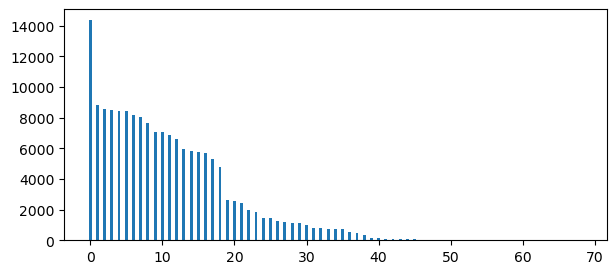

In [88]:
# Feature selection
def select_features(x_train, y_train, x_test):
    # configure to select all features
    fs = SelectKBest(score_func=f_classif,k='all')
    # learn relationship from training data
    fs.fit(x_train, y_train)
     # transform train input data
    x_train_fs = fs.transform(x_train)
    # transform test input data
    x_test_fs = fs.transform(x_test)
    return fs

fs = select_features(x_train, y_train, x_test)

# Show best k features with their scores
feature_scores = pd.DataFrame({'Feature': fs.feature_names_in_, 'Score': fs.scores_})
feature_scores = feature_scores.sort_values(by=['Score'],ascending=False)
selected_features = feature_scores.head(19)['Feature'].tolist()
print(selected_features)
print(tabulate(feature_scores.head(19), headers=["Feature","Score"], tablefmt="fancy_grid"))

# Write the list of selected features to a CSV file
with open('selected_features.csv', 'w') as f:
    writer = csv.writer(f)
    writer.writerow(selected_features)

# creating the bar plot
fig = plt.figure(figsize = (7, 3))
plt.bar(range(0,len(feature_scores)), feature_scores["Score"].tolist(),width = 0.4)
plt.show()

In [90]:
# Keep only the selected features
x_train = x_train[selected_features]
x_test = x_test[selected_features]
print(x_train.info())
print(x_train.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38019 entries, 51981 to 23720
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Protocol          38019 non-null  float64
 1   Bwd Pkt Len Std   38019 non-null  float64
 2   Pkt Len Std       38019 non-null  float64
 3   Bwd Pkt Len Max   38019 non-null  float64
 4   Bwd Pkt Len Mean  38019 non-null  float64
 5   Bwd Seg Size Avg  38019 non-null  float64
 6   Pkt Len Max       38019 non-null  float64
 7   Pkt Len Min       38019 non-null  float64
 8   Bwd Pkt Len Min   38019 non-null  float64
 9   Pkt Len Var       38019 non-null  float64
 10  Pkt Len Mean      38019 non-null  float64
 11  Pkt Size Avg      38019 non-null  float64
 12  Fwd IAT Std       38019 non-null  float64
 13  Idle Max          38019 non-null  float64
 14  Fwd IAT Max       38019 non-null  float64
 15  Flow IAT Max      38019 non-null  float64
 16  Idle Mean         38019 non-null  fl

In [91]:
# Plot ROC Curve
def roc_plot(fpr, tpr, roc_auc):
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
   
# Generate metrics output
def analyse(trial, pr, metrics_array, metrics_sum):
    best_accuracy = trial.value
    best_precision = metrics_array[trial.number][0]
    best_recall = metrics_array[trial.number][1]
    best_f1 = metrics_array[trial.number][2]
    best_precision_sum = metrics_sum[trial.number][0]
    best_recall_sum = metrics_sum[trial.number][1]
    best_f1_sum = metrics_sum[trial.number][2]
    metrics_table = [["Precision",best_precision[0],best_precision[1]],["Recall",best_recall[0],best_recall[1]],
                     ["F1-score",best_f1[0],best_f1[1]]]
    best_fpr = pr[trial.number][0]
    best_tpr = pr[trial.number][1]
    roc_auc = auc(best_fpr, best_tpr)
    print("Accuracy: ", best_accuracy)
    print(tabulate(metrics_table, headers=["Metrics","Normal Class", "Anomaly Class"], tablefmt="fancy_grid"))
    roc_plot(best_fpr, best_tpr, roc_auc)
    return [best_accuracy, roc_auc, best_precision_sum, best_recall_sum, best_f1_sum]

Accuracy:  0.6971277770958635
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.623407 │        0.92     │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.959281 │        0.446923 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.755705 │        0.601598 │
╘═══════════╧════════════════╧═════════════════╛


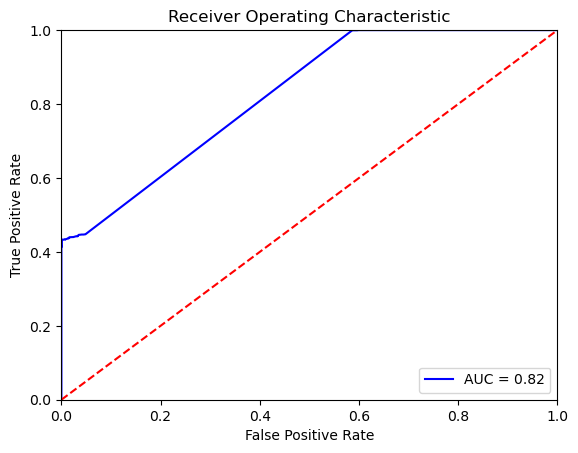

['Naive Bayes classifier', 0.6971277770958635, 0.8241581546271205, 0.6971277770958635, 0.6971277770958635, 0.6971277770958635]
{'NB_alpha': 0.471104193555588, 'NB_binarize': 0.9335267213483536}


['models/NB_trained_model.pkl']

In [92]:
# Naive Bayes classifier

# Define objective function
def objective(trial):
    # Parameters
    alpha = trial.suggest_float('NB_alpha', 0.01, 1, log=True)
    binarize = trial.suggest_float('NB_binarize', 0, 1)
    # Model training
    clf = BernoulliNB(alpha=alpha, binarize=binarize)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_NB.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_NB.append((precision, recall, f1))
    metrics_NB_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_NB = []
metrics_NB = []
metrics_NB_sum = []
study_NB = optuna.create_study(direction='maximize')
study_NB.optimize(objective, n_trials=4)

# Select best trial and analyse the result
trial_NB = study_NB.best_trial
NB_params = trial_NB.params
NB_result = analyse(trial_NB, pr_NB, metrics_NB, metrics_NB_sum)
NB_result.insert(0, 'Naive Bayes classifier')
print(NB_result)
print(NB_params)

# Export the model
NB_clf = BernoulliNB(alpha=NB_params['NB_alpha'],binarize=NB_params['NB_binarize'])
NB_clf.fit(x_train, y_train)
joblib.dump(NB_clf,'models/NB_trained_model.pkl')

Accuracy:  0.9838590892353013
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.983534 │        0.984169 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.983411 │        0.984287 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.983473 │        0.984228 │
╘═══════════╧════════════════╧═════════════════╛


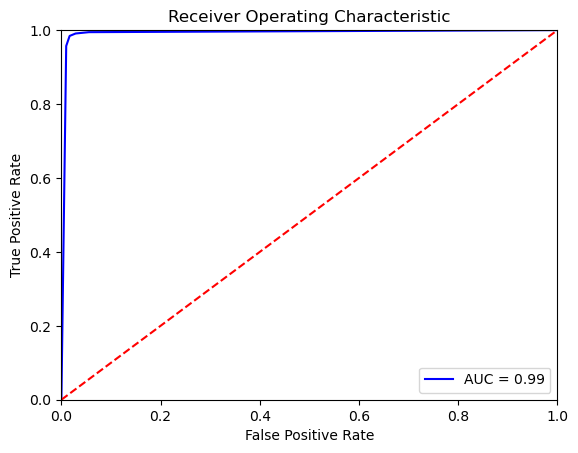

['K Nearest Neighbor', 0.9838590892353013, 0.9917994810447285, 0.9838590892353013, 0.9838590892353013, 0.9838590892353013]
{'KNN_n_neighbors': 4}


['models/KNN_trained_model.pkl']

In [93]:
# K Nearest Neighbors (KNN) classification model

# Define objective function
def objective(trial):
    # Parameters
    n_neighbors = trial.suggest_int('KNN_n_neighbors', 2, 16, log=True)
    # Model training
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_KNN.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_KNN.append((precision, recall, f1))
    metrics_KNN_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_KNN = []
metrics_KNN = []
metrics_KNN_sum = []
study_KNN = optuna.create_study(direction='maximize')
study_KNN.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_KNN = study_KNN.best_trial
KNN_params = trial_KNN.params
KNN_result = analyse(trial_KNN, pr_KNN, metrics_KNN, metrics_KNN_sum)
KNN_result.insert(0, 'K Nearest Neighbor')
print(KNN_result)
print(KNN_params)

# Export the model
KNN_clf = KNeighborsClassifier(n_neighbors=KNN_params['KNN_n_neighbors'])
KNN_clf.fit(x_train, y_train)
joblib.dump(KNN_clf,'models/KNN_trained_model.pkl')

Accuracy:  0.8284030931631275
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.979024 │        0.754011 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.662813 │        0.986446 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.790468 │        0.854708 │
╘═══════════╧════════════════╧═════════════════╛


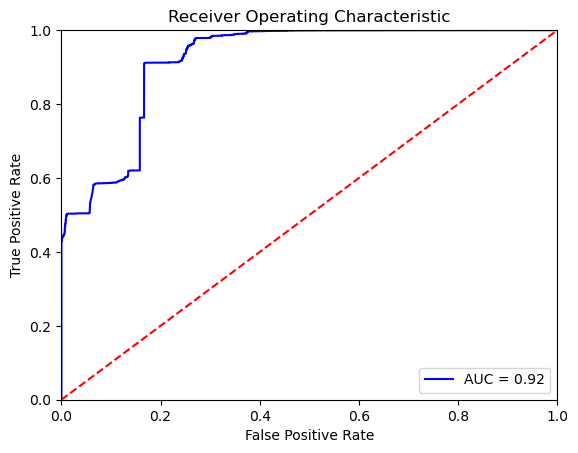

['Logistic Regression', 0.8284030931631275, 0.9180616579980416, 0.8284030931631275, 0.8284030931631275, 0.8284030931631275]
{'LR_C': 517.1043946376852, 'LR_max_iter': 300}


['models/LG_trained_model.pkl']

In [94]:
# Logistic Regression

# Define objective function
def objective(trial):
    # Parameters
    C = trial.suggest_loguniform('LR_C', 1e-4, 1e4)
    max_iter = trial.suggest_int('LR_max_iter', 100, 1000, step=100)
    # Model training
    clf = LogisticRegression(C=C, max_iter=max_iter)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.decision_function(x_test), drop_intermediate=False)
    pr_LG.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_LG.append((precision, recall, f1))
    metrics_LG_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_LG = []
metrics_LG = []
metrics_LG_sum = []
study_LG = optuna.create_study(direction='maximize')
study_LG.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_LG = study_LG.best_trial
LG_params = trial_LG.params
LG_result = analyse(trial_LG, pr_LG, metrics_LG, metrics_LG_sum)
LG_result.insert(0, 'Logistic Regression')
print(LG_result)
print(LG_params)

# Export the model
LG_clf = LogisticRegression(C=LG_params['LR_C'],max_iter=LG_params['LR_max_iter'])
LG_clf.fit(x_train, y_train)
joblib.dump(LG_clf,'models/LG_trained_model.pkl')

Accuracy:  0.9610285994844728
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.986189 │        0.939411 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.933266 │        0.987525 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.958998 │        0.962868 │
╘═══════════╧════════════════╧═════════════════╛


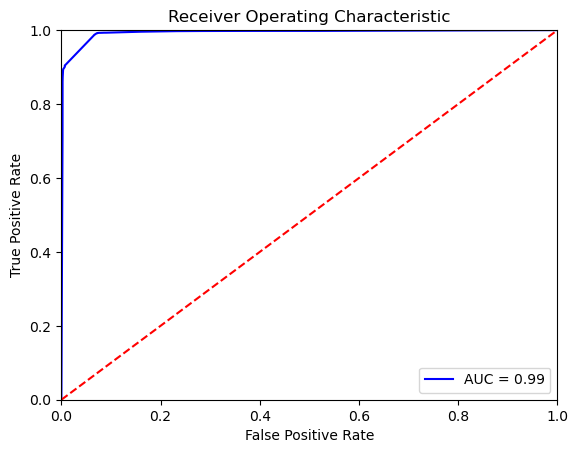

['Decision Tree Classifier', 0.9610285994844728, 0.9928273836751995, 0.9610285994844728, 0.9610285994844728, 0.9610285994844728]
{'DT_max_depth': 11, 'DT_max_features': 10}


['models/DT_trained_model.pkl']

In [95]:
# Decision Tree Classifier

# Define objective function
def objective(trial):
    # Parameters
    max_depth = trial.suggest_int('DT_max_depth', 2, 16)
    max_features = trial.suggest_int('DT_max_features', 2, 10)
    # Model training
    clf = DecisionTreeClassifier(max_features=max_features, max_depth=max_depth)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_DT.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_DT.append((precision, recall, f1))
    metrics_DT_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_DT = []
metrics_DT = []
metrics_DT_sum = []
study_DT = optuna.create_study(direction='maximize')
study_DT.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_DT = study_DT.best_trial
DT_params = trial_DT.params
DT_result = analyse(trial_DT, pr_DT, metrics_DT, metrics_DT_sum)
DT_result.insert(0, 'Decision Tree Classifier')
print(DT_result)
print(DT_params)

# Export the model
DT_clf = DecisionTreeClassifier(max_features=DT_params['DT_max_features'],max_depth=DT_params['DT_max_depth'])
DT_clf.fit(x_train, y_train)
joblib.dump(DT_clf,'models/DT_trained_model.pkl')

Accuracy:  0.8261323186449
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.977629 │        0.751784 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.659042 │        0.985606 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.787328 │        0.852961 │
╘═══════════╧════════════════╧═════════════════╛


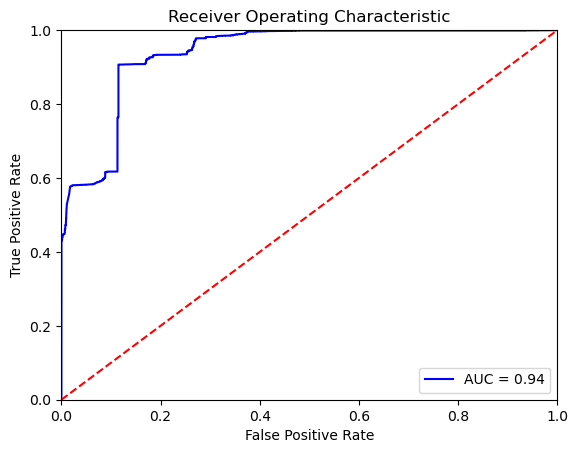

['Support Vector Machine', 0.8261323186449, 0.9376658761787393, 0.8261323186449, 0.8261323186449, 0.8261323186449]
{'SVC_C': 10.042238041964087}


['models/SVM_trained_model.pkl']

In [96]:
# Support Vector Machine

# Define objective function
def objective(trial):
    # Parameters
    C = trial.suggest_loguniform('SVC_C', 0.1, 100)
    # Model training
    clf = LinearSVC(C=C)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.decision_function(x_test), drop_intermediate=False)
    pr_SVM.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_SVM.append((precision, recall, f1))
    metrics_SVM_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_SVM = []
metrics_SVM = []
metrics_SVM_sum = []
study_SVM = optuna.create_study(direction='maximize')
study_SVM.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_SVM = study_SVM.best_trial
SVM_params = trial_SVM.params
SVM_result = analyse(trial_SVM, pr_SVM, metrics_SVM, metrics_SVM_sum)
SVM_result.insert(0, 'Support Vector Machine')
print(SVM_result)
print(SVM_params)

# Export the model
SVM_clf = LinearSVC(C=SVM_params["SVC_C"])
SVM_clf.fit(x_train, y_train)
joblib.dump(SVM_clf,'models/SVM_trained_model.pkl')

Accuracy:  0.9552596047624893
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.986145 │        0.929345 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.921327 │        0.987645 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.952635 │        0.957609 │
╘═══════════╧════════════════╧═════════════════╛


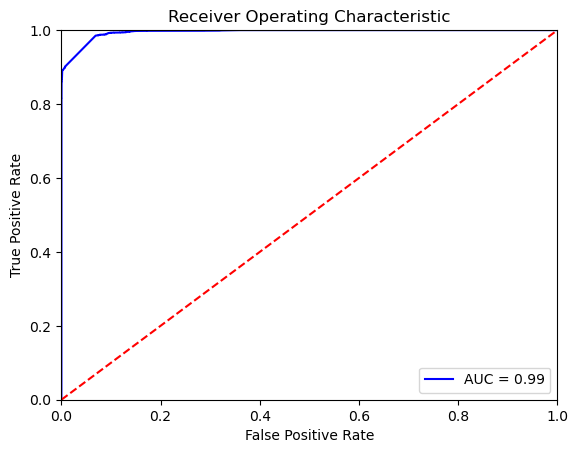

['Random Forest Classifier', 0.9552596047624893, 0.9947117926903164, 0.9552596047624893, 0.9552596047624893, 0.9552596047624893]
{'RF_max_depth': 8, 'RF_min_samples_split': 11, 'RF_min_samples_leaf': 4, 'RF_n_estimators': 45}


['models/RF_trained_model.pkl']

In [97]:
# Random Forest Classifier

# Define objective function
def objective(trial):
    # Parameters
    max_depth = trial.suggest_int('RF_max_depth', 2, 16)
    min_samples_split = trial.suggest_int('RF_min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('RF_min_samples_leaf', 1, 10)
    n_estimators = trial.suggest_int('RF_n_estimators', 10, 50)
    # Model training
    clf = RandomForestClassifier(min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_depth=max_depth, n_estimators=n_estimators)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_RF.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_RF.append((precision, recall, f1))
    metrics_RF_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_RF = []
metrics_RF = []
metrics_RF_sum = []
study_RF = optuna.create_study(direction='maximize')
study_RF.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_RF = study_RF.best_trial
RF_params = trial_RF.params
RF_result = analyse(trial_RF, pr_RF, metrics_RF, metrics_RF_sum)
RF_result.insert(0, 'Random Forest Classifier')
print(RF_result)
print(RF_params)

# Export the model
RF_clf = RandomForestClassifier(min_samples_split=RF_params["RF_min_samples_split"], min_samples_leaf=RF_params["RF_min_samples_leaf"], 
                                max_depth=RF_params["RF_max_depth"], n_estimators=RF_params["RF_n_estimators"])
RF_clf.fit(x_train, y_train)
joblib.dump(RF_clf,'models/RF_trained_model.pkl')

Accuracy:  0.9640972136982938
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.993837 │        0.938958 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.932261 │        0.994482 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.962065 │        0.965923 │
╘═══════════╧════════════════╧═════════════════╛


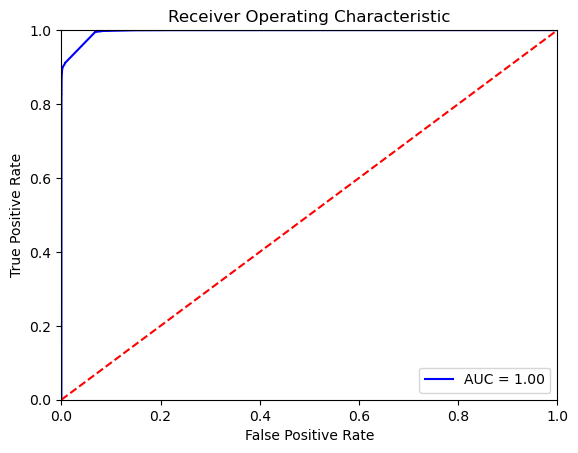

['Gradient Boosting Classifier', 0.9640972136982938, 0.9961577167451374, 0.9640972136982938, 0.9640972136982938, 0.9640972136982938]
{'GB_learning_rate': 0.08821766986980492, 'GB_max_depth': 11, 'GB_min_samples_split': 5, 'GB_min_samples_leaf': 7, 'GB_n_estimators': 37}


['models/GB_trained_model.pkl']

In [98]:
# Gradient Boosting Classifier

# Define objective function
def objective(trial):
    # Parameters
    learning_rate = trial.suggest_float('GB_learning_rate', 0.01, 0.1)
    max_depth = trial.suggest_int('GB_max_depth', 2, 16)
    min_samples_split = trial.suggest_int('GB_min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('GB_min_samples_leaf', 1, 10)
    n_estimators = trial.suggest_int('GB_n_estimators', 10, 50)
    # Model training
    clf = GradientBoostingClassifier(learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_GB.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_GB.append((precision, recall, f1))
    metrics_GB_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_GB = []
metrics_GB = []
metrics_GB_sum = []
study_GB = optuna.create_study(direction='maximize')
study_GB.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_GB = study_GB.best_trial
GB_params = trial_GB.params
GB_result = analyse(trial_GB, pr_GB, metrics_GB, metrics_GB_sum)
GB_result.insert(0, 'Gradient Boosting Classifier')
print(GB_result)
print(GB_params)

# Export the model
GB_clf = GradientBoostingClassifier(learning_rate=GB_params["GB_learning_rate"], min_samples_leaf=GB_params["GB_min_samples_leaf"], 
                                    max_depth=GB_params["GB_max_depth"], n_estimators=GB_params["GB_n_estimators"], 
                                    min_samples_split=GB_params["GB_min_samples_split"])
GB_clf.fit(x_train, y_train)
joblib.dump(GB_clf,'models/GB_trained_model.pkl')

Accuracy:  0.9632993740027004
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.990535 │        0.940066 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.933769 │        0.991484 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.961315 │        0.96509  │
╘═══════════╧════════════════╧═════════════════╛


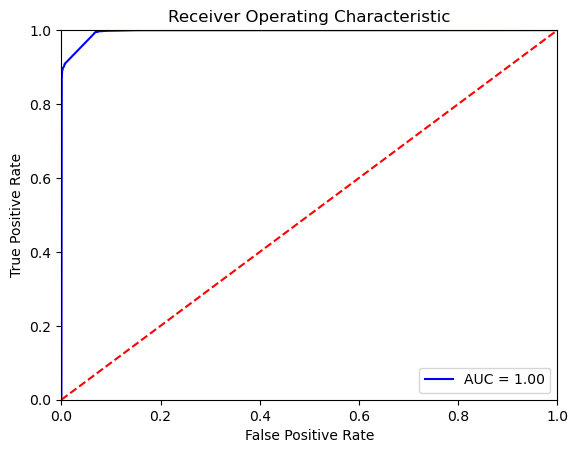

['AdaBoost Classifier', 0.9632993740027004, 0.9957662187767707, 0.9632993740027004, 0.9632993740027004, 0.9632993740027004]
{'AB_learning_rate': 0.08173769989933914, 'AB_n_estimators': 24, 'AB_algorithm': 'SAMME', 'AB_max_depth': 9}


['models/AB_trained_model.pkl']

In [99]:
# AdaBoost classifier

# Define objective function
def objective(trial):
    # Parameters
    learning_rate = trial.suggest_float('AB_learning_rate', 0.01, 0.1)
    n_estimators = trial.suggest_int('AB_n_estimators', 10, 50)
    algorithm = trial.suggest_categorical('AB_algorithm', ['SAMME', 'SAMME.R'])
    base_estimator = DecisionTreeClassifier(max_depth=trial.suggest_int('AB_max_depth', 1, 10))
    # Model training
    clf = AdaBoostClassifier(learning_rate=learning_rate,n_estimators=n_estimators,algorithm=algorithm,base_estimator=base_estimator)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_AB.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_AB.append((precision, recall, f1))
    metrics_AB_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_AB = []
metrics_AB = []
metrics_AB_sum = []
study_AB = optuna.create_study(direction='maximize')
study_AB.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_AB = study_AB.best_trial
AB_params = trial_AB.params
AB_result = analyse(trial_AB, pr_AB, metrics_AB, metrics_AB_sum)
AB_result.insert(0, 'AdaBoost Classifier')
print(AB_result)
print(AB_params)

# Export the model
AB_clf = AdaBoostClassifier(learning_rate=AB_params["AB_learning_rate"], algorithm=AB_params["AB_algorithm"], 
                            base_estimator=DecisionTreeClassifier(max_depth=AB_params["AB_max_depth"]), n_estimators=AB_params["AB_n_estimators"])
AB_clf.fit(x_train, y_train)
joblib.dump(AB_clf,'models/AB_trained_model.pkl')

Accuracy:  0.9869277034491224
╒═══════════╤════════════════╤═════════════════╕
│ Metrics   │   Normal Class │   Anomaly Class │
╞═══════════╪════════════════╪═════════════════╡
│ Precision │       0.989755 │        0.984263 │
├───────────┼────────────────┼─────────────────┤
│ Recall    │       0.983411 │        0.990284 │
├───────────┼────────────────┼─────────────────┤
│ F1-score  │       0.986573 │        0.987265 │
╘═══════════╧════════════════╧═════════════════╛


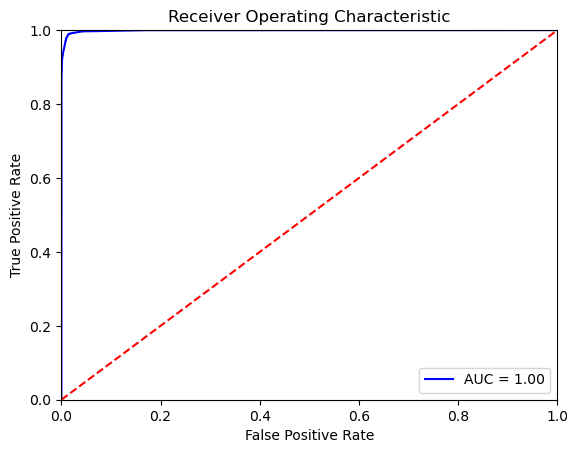

['LightGBM Classifier', 0.9869277034491224, 0.9989324290123707, 0.9869277034491224, 0.9869277034491224, 0.9869277034491224]
{'LGBM_learning_rate': 0.09515451312260331, 'LGBM_max_depth': 10, 'LGBM_min_child_samples': 5}


['models/LGBM_trained_model.pkl']

In [100]:
# LightGBM Classifier

# Define objective function
def objective(trial):
    # Parameters
    learning_rate = trial.suggest_float('LGBM_learning_rate', 0.01, 0.1)
    max_depth = trial.suggest_int('LGBM_max_depth', 2, 16)
    min_child_samples = trial.suggest_int('LGBM_min_child_samples', 1, 20)
    # Model training
    clf = LGBMClassifier(learning_rate=learning_rate,max_depth=max_depth,min_child_samples=min_child_samples)
    clf.fit(x_train, y_train)
    # Performance metrics
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, threshold = roc_curve(y_test, clf.predict_proba(x_test)[:, 1], drop_intermediate=False)
    pr_LGBM.append((fpr, tpr))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
    precision_sum, recall_sum, f1_sum, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    metrics_LGBM.append((precision, recall, f1))
    metrics_LGBM_sum.append((precision_sum, recall_sum, f1_sum))
    return accuracy

# Create Optuna study and optimize objective function
pr_LGBM = []
metrics_LGBM = []
metrics_LGBM_sum = []
study_LGBM = optuna.create_study(direction='maximize')
study_LGBM.optimize(objective, n_trials=10)

# Select best trial and analyse the result
trial_LGBM = study_LGBM.best_trial
LGBM_params = trial_LGBM.params
LGBM_result = analyse(trial_LGBM, pr_LGBM, metrics_LGBM, metrics_LGBM_sum)
LGBM_result.insert(0, 'LightGBM Classifier')
print(LGBM_result)
print(LGBM_params)

# Export the model
LGBM_clf = LGBMClassifier(learning_rate=LGBM_params["LGBM_learning_rate"], min_child_samples=LGBM_params["LGBM_min_child_samples"], max_depth=LGBM_params["LGBM_max_depth"])
LGBM_clf.fit(x_train, y_train)
joblib.dump(LGBM_clf,'models/LGBM_trained_model.pkl')

In [101]:
# Summary

data = [NB_result, KNN_result, LG_result, DT_result, SVM_result, RF_result, GB_result, AB_result, LGBM_result]

col_names = ["Model", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒══════════════════════════════╤════════════╤══════════╤═════════════╤══════════╤════════════╕
│ Model                        │   Accuracy │      AUC │   Precision │   Recall │   F1-Score │
╞══════════════════════════════╪════════════╪══════════╪═════════════╪══════════╪════════════╡
│ Naive Bayes classifier       │   0.697128 │ 0.824158 │    0.697128 │ 0.697128 │   0.697128 │
├──────────────────────────────┼────────────┼──────────┼─────────────┼──────────┼────────────┤
│ K Nearest Neighbor           │   0.983859 │ 0.991799 │    0.983859 │ 0.983859 │   0.983859 │
├──────────────────────────────┼────────────┼──────────┼─────────────┼──────────┼────────────┤
│ Logistic Regression          │   0.828403 │ 0.918062 │    0.828403 │ 0.828403 │   0.828403 │
├──────────────────────────────┼────────────┼──────────┼─────────────┼──────────┼────────────┤
│ Decision Tree Classifier     │   0.961029 │ 0.992827 │    0.961029 │ 0.961029 │   0.961029 │
├──────────────────────────────┼────────────┼─────